In [41]:
from datascience import *
import numpy as np
import matplotlib
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import warnings
warnings.simplefilter("ignore")

## Review

In [42]:
def standard_units(any_numbers):
    "Convert any array of numbers to standard units."
    return (any_numbers - np.mean(any_numbers))/np.std(any_numbers)  

def correlation(t, x, y):
    return np.mean(standard_units(t.column(x))*standard_units(t.column(y)))

## New material

In [43]:
all_sales = Table.read_table('house.csv')

In [44]:
sales = all_sales.where('Bldg Type', '1Fam').where('Sale Condition', 'Normal').select(
    'SalePrice', '1st Flr SF', '2nd Flr SF', 
    'Total Bsmt SF', 'Garage Area', 
    'Wood Deck SF', 'Open Porch SF', 'Lot Area', 
    'Year Built', 'Yr Sold')

#### Exploration step

In [45]:
sales.num_rows

2002

In [46]:
sales.sample(6).show(6)

SalePrice,1st Flr SF,2nd Flr SF,Total Bsmt SF,Garage Area,Wood Deck SF,Open Porch SF,Lot Area,Year Built,Yr Sold
114000,709,308,346,308,0,0,9143,1900,2008
200000,1107,983,1107,484,235,204,10382,1973,2009
137000,935,0,935,288,180,0,13526,1965,2006
68000,715,0,715,660,0,0,10914,1929,2006
200000,1290,0,1282,662,168,0,6762,2007,2009
153500,1074,0,1056,495,0,88,10140,1975,2006


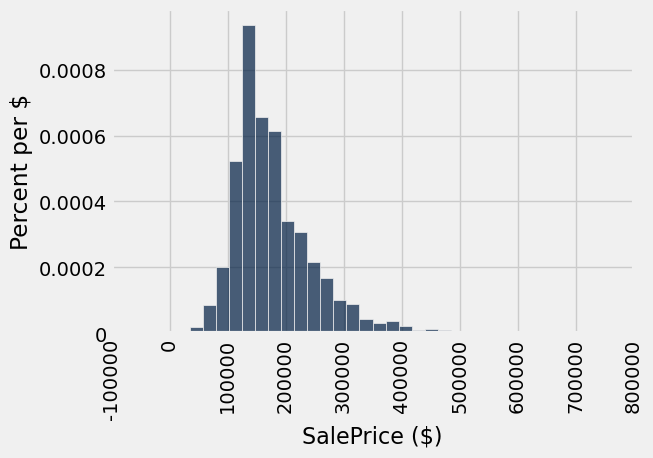

In [47]:
sales.hist('SalePrice', bins=32, unit='$')

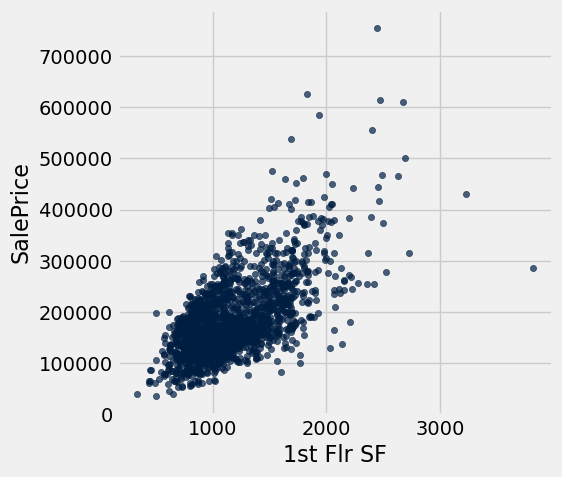

In [48]:
sales.scatter('1st Flr SF', 'SalePrice')

In [49]:
correlation(sales, 'SalePrice', '1st Flr SF')

0.64246625410302249

- It's always a good idea to take a look at each of the variables in some capacity.
    -  To make the demo shorter we will just look at the $r$ for each variable, but you should look at the plots as well.

In [50]:
for label in sales.labels:
    print('Correlation of', label, 'and SalePrice:\t', correlation(sales, label, 'SalePrice'))

Correlation of SalePrice and SalePrice:	 1.0
Correlation of 1st Flr SF and SalePrice:	 0.642466254103
Correlation of 2nd Flr SF and SalePrice:	 0.35752189428
Correlation of Total Bsmt SF and SalePrice:	 0.652978626757
Correlation of Garage Area and SalePrice:	 0.638594485252
Correlation of Wood Deck SF and SalePrice:	 0.352698666195
Correlation of Open Porch SF and SalePrice:	 0.336909417026
Correlation of Lot Area and SalePrice:	 0.290823455116
Correlation of Year Built and SalePrice:	 0.565164753714
Correlation of Yr Sold and SalePrice:	 0.0259485790807


______

For simplicity, we will use the five variables having the highest correlation coefficients with `SalePrice`.

In [35]:
sales = sales.select(0, 1, 2, 3, 4, 8)
sales.show(3)

SalePrice,1st Flr SF,2nd Flr SF,Total Bsmt SF,Garage Area,Year Built
215000,1656,0,1080,528,1960
105000,896,0,882,730,1961
172000,1329,0,1329,312,1958


#### Train-test split

In [36]:
split_point = round(sales.num_rows*(70/100))
sales_shuffled = sales.sample(with_replacement = False)

In [37]:
train = sales_shuffled.take(np.arange(split_point))
test = sales_shuffled.take(np.arange(split_point, sales.num_rows))

### How is an MLR estimate calculated?

**Task**: Find the best slopes for the linear regression model:

$$\text{estimate of sale price} = a*\text{1st floor SF} + b*\text{2nd floor SF} + c*\text{Bsmt SF} + d*\text{Garage Area} + e*\text{Year Built} + f$$

We are going to find the best slopes in the model by minimization. Let's set up our equation to do this in a function!

In [38]:
def sales_train_rmse(a,b,c,d,e,f):

    y = train.column('SalePrice')
    
    first_floor = train.column('1st Flr SF')
    second_floor = train.column('2nd Flr SF')
    basement = train.column('Total Bsmt SF')
    garage = train.column('Garage Area')
    year = train.column('Year Built')
    
    estimate = a*first_floor + b*second_floor + c*basement + d*garage + e*year + f
    
    return (np.mean((y - estimate) ** 2)) ** 0.5

#### Using `minimize()` for multiple linear regression

```python
minimize(f, start=starting_values, smooth=True)
```

The `smooth` argument will always read `True` for our purposes!

You do not need to be concerned with how to supply the `start` argument in `minimize()`. We will do this for you when necessary. In this case, I generated the starting slopes at random from a normal distribution with mean 10 and standard deviation of 1.

In [39]:
example_slopes = np.random.normal(10, 1, len(train.row(0)))
example_slopes

array([  9.80232212,  10.7393894 ,   9.53138585,   8.78865667,
        10.25764135,  11.79000468])

In [40]:
minimize(sales_train_rmse, start=example_slopes, smooth=True)

array([  8.48551853e+01,   7.76852439e+01,   4.63369645e+01,
         5.06240038e+01,   5.54544207e+02,  -1.10758549e+06])

**STOP**

**Task**: Find the fitted values (sale price predictions on the *training* set) for our model.

In [41]:
def sales_estimate(data, a,b,c,d,e,f):

    first_floor = data.column('1st Flr SF')
    second_floor = data.column('2nd Flr SF')
    basement = data.column('Total Bsmt SF')
    garage = data.column('Garage Area')
    year = data.column('Year Built')
    
    return a*first_floor + b*second_floor + c*basement + d*garage + e*year + f

In [42]:
fitted_values = sales_estimate(train, 7.99370803e+01,   7.72401282e+01,   5.23616519e+01,
         4.68487623e+01,   5.61174620e+02,  -1.11909133e+06)

In [43]:
fitted_values

array([ 255916.7839127,  159120.784342 ,  116894.4928663, ...,
        126508.0414198,  284520.7797633,  133825.4559516])

### How can we evaluate our model fit?

In [48]:
fit_table = Table().with_columns('Fitted',  fitted_values,
                                'Residuals', (train.column('SalePrice') - fitted_values))

In [49]:
fit_table.sample(3)

Fitted,Residuals
239341,30448.8
274900,-2399.95
253364,-53363.8


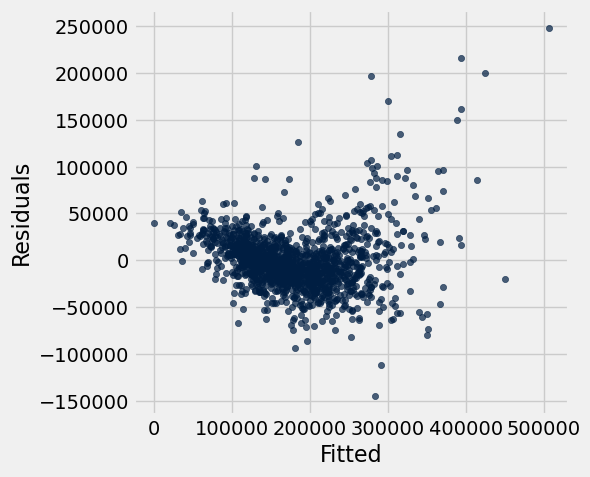

In [50]:
fit_table.scatter('Fitted', 'Residuals')

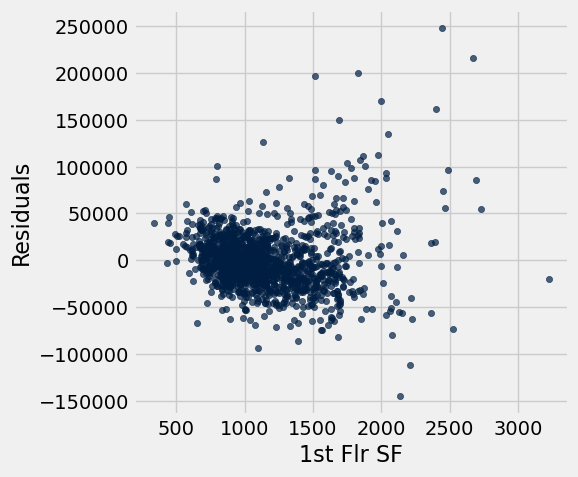

In [51]:
fit_table = fit_table.with_columns('1st Flr SF', train.column('1st Flr SF'),
                                  'Garage Area', train.column('Garage Area'))
fit_table.scatter('1st Flr SF', 'Residuals')

### How we evaluate the accuracy of an MLR model?

**Task** calculate the RMSE between:

- the predicted house prices of the testing data
- the actual house prices of the testing data

In [52]:
def sales_train_rmse(a,b,c,d,e,f):

    y = train.column('SalePrice')
    
    first_floor = train.column('1st Flr SF')
    second_floor = train.column('2nd Flr SF')
    basement = train.column('Total Bsmt SF')
    garage = train.column('Garage Area')
    year = train.column('Year Built')
    
    estimate = a*first_floor + b*second_floor + c*basement + d*garage + e*year + f
    
    return (np.mean((y - estimate) ** 2)) ** 0.5

In [53]:
minimize(sales_train_rmse, start=example_slopes, smooth=True)

array([  8.48551853e+01,   7.76852439e+01,   4.63369645e+01,
         5.06240038e+01,   5.54544207e+02,  -1.10758549e+06])

In [54]:
def sales_test_rmse(a,b,c,d,e,f):

    y = test.column('SalePrice')
    
    first_floor = test.column('1st Flr SF')
    second_floor = test.column('2nd Flr SF')
    basement = test.column('Total Bsmt SF')
    garage = test.column('Garage Area')
    year = test.column('Year Built')
    
    estimate = a*first_floor + b*second_floor + c*basement + d*garage + e*year + f
    
    return (np.mean((y - estimate) ** 2)) ** 0.5

In [55]:
sales_test_rmse(8.57001834e+01,   8.31651700e+01,   4.78808900e+01,
         5.18150471e+01,   5.19933651e+02,  -1.04414307e+06)

31109.360327833005

**STOP**

### We can bring nearest neighbors to linear regression, too!

In [56]:
def distance(point1, point2):
    """Returns the distance between point1 and point2
    where each argument is an array 
    consisting of the coordinates of the point"""
    return np.sum((point1-point2)**2) ** 0.5

def all_distances(training, new_row, y_name):
    """Returns an array of distances
    between each point in the training set
    and the new point (which is a row of attributes)"""
    attributes = training.drop(y_name)
    def distance_from_new(row):
        return distance(make_array(new_row), make_array(row))
    return attributes.apply(distance_from_new)


def table_with_distances(training, new_point, y_name):
    """Augments the training table 
    with a column of distances from new_point"""
    return training.with_column('Distance', all_distances(training, new_point, y_name))


def nearest(training, new_point, y_name, k):
    """Returns a table of the k rows of the augmented table
    corresponding to the k smallest distances"""
    with_dists = table_with_distances(training, new_point, y_name)
    sorted_by_distance = with_dists.sort('Distance')
    nearest_neighbors_table = sorted_by_distance.take(np.arange(k))
    return nearest_neighbors_table


In [57]:
example_row = test.drop(0).row(0)
example_row

Row(1st Flr SF=851, 2nd Flr SF=585, Total Bsmt SF=585.0, Garage Area=228.0, Year Built=1921)

In [58]:
nearest(train, example_row, 'SalePrice', 5)

SalePrice,1st Flr SF,2nd Flr SF,Total Bsmt SF,Garage Area,Year Built,Distance
165000,900,602,602,180,1923,72.7118
125000,842,630,702,250,1925,127.652
106900,736,554,554,200,1900,127.953
165250,798,504,680,224,1940,137.011
79000,889,551,540,352,1900,142.976


In [59]:
def nn_5_regression_estimate(new_point):
    return np.average(nearest(train, new_point, 'SalePrice', 5).column('SalePrice'))

In [60]:
nn_5_regression_estimate(example_row)

128230.0

Perform a 5-nearest neighbors regression on all testing points.

In [61]:
predictions = test.drop('SalePrice').apply(nn_5_regression_estimate)

Calculate the $\text{RMSE}$ for our model!

In [62]:
(np.mean((test.column('SalePrice') - predictions) ** 2)) ** 0.5

31675.930242703718